# Production ops — drift, active learning, robustness, memory budgets

The operational toolkit for running `betula-cluster` on live data:

- **drift monitoring** with `snapshot()` + `compare_snapshots()`,
- **active learning** — surface the points worth labelling,
- **robust insertion** (`huber_k`) so stream outliers can't drag a centroid,
- **memory budgets** (`memory_budget_mb`) instead of hand-tuning `max_leaves`.

```bash
pip install betula-cluster matplotlib seaborn pandas scikit-learn
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs

from betula_cluster import Betula

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
rng = np.random.default_rng(0)

## Drift monitoring — `snapshot` + `compare_snapshots`

Fit on this month's data, snapshot the cluster geometry; next month, fit again and compare. Each new
cluster is matched to its nearest old centroid; the report gives the centroid shift (in radius
units) and the mass ratio — an early warning when the world moves.

In [2]:
base = [[0, 0], [8, 0], [0, 8]]
X0, _ = make_blobs(n_samples=6000, centers=base, cluster_std=0.7, random_state=0)
e0 = Betula(n_clusters=3, method="gmm", threshold=0.1, seed=1).fit(X0.astype(np.float64))
s0 = e0.snapshot()

shifted = [[1.5, 1.0], [9.0, 0.5], [0.0, 8.0]]  # two clusters drift, one stays
X1, _ = make_blobs(n_samples=6000, centers=shifted, cluster_std=0.7, random_state=1)
e1 = Betula(n_clusters=3, method="gmm", threshold=0.1, seed=1).fit(X1.astype(np.float64))
s1 = e1.snapshot()

report = Betula.compare_snapshots(s0, s1)
drift = pd.DataFrame(report["matches"]).round(3)
drift

,after,before,centroid_shift,centroid_shift_radii,mass_ratio
0,0,2,0.043,0.043,1.0
1,1,0,1.122,1.134,1.0
2,2,1,1.843,1.865,1.0


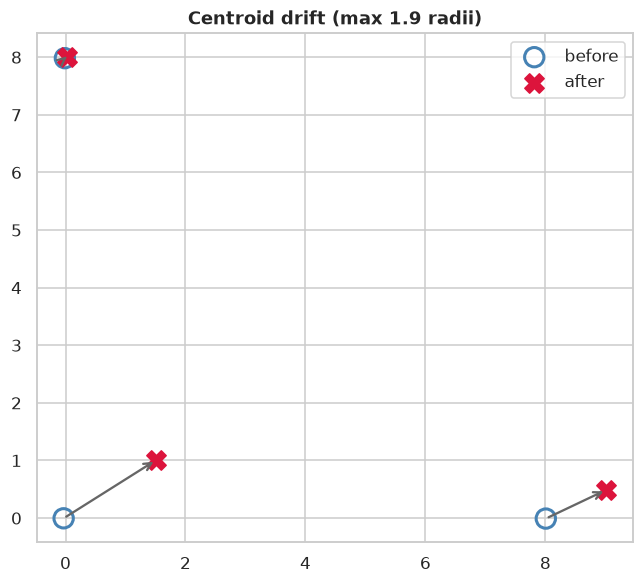

In [3]:
cb, ca = np.array(s0["centers"]), np.array(s1["centers"])
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(*cb.T, s=160, marker="o", facecolor="none", edgecolor="steelblue", linewidth=2, label="before")
ax.scatter(*ca.T, s=160, marker="X", color="crimson", label="after")
for m in report["matches"]:
    a, b = ca[m["after"]], cb[m["before"]]
    ax.annotate("", xy=a, xytext=b, arrowprops=dict(arrowstyle="->", color="0.4", lw=1.5))
ax.legend()
ax.set_title(f"Centroid drift (max {report['max_centroid_shift_radii']:.1f} radii)")
plt.show()

## Active learning — which points to label?

`active_learning_batch` returns the most informative rows: lowest-confidence ("uncertain", at
cluster boundaries) or highest "outlier" score. Label these for the best return on human effort.

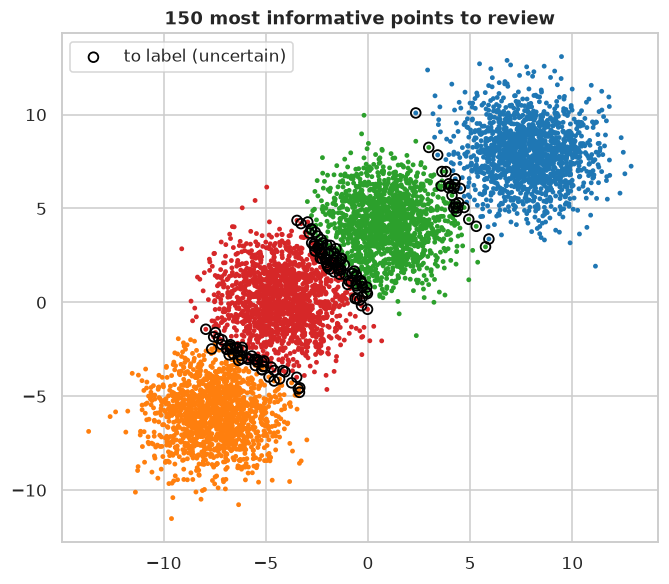

In [4]:
Xa, _ = make_blobs(n_samples=6000, centers=4, cluster_std=1.6, random_state=3)
Xa = Xa.astype(np.float64)
ea = Betula(n_clusters=4, method="gmm", threshold=0.1, seed=1).fit(Xa)
to_label = np.asarray(ea.active_learning_batch(Xa, n=150, strategy="uncertain"))

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(x=Xa[:, 0], y=Xa[:, 1], hue=np.asarray(ea.predict(Xa)), palette="tab10", s=10, linewidth=0, legend=False, ax=ax)
ax.scatter(*Xa[to_label].T, s=40, facecolor="none", edgecolor="black", linewidth=1.2, label="to label (uncertain)")
ax.legend()
ax.set_title("150 most informative points to review")
plt.show()

## Robust insertion — outliers can't drag the centroid

Stream a tight cluster, then inject extreme outliers. With `huber_k` set, each incoming point is
clamped to within `k` per-dimension stds of its microcluster before it is folded in, so the centroid
barely moves.

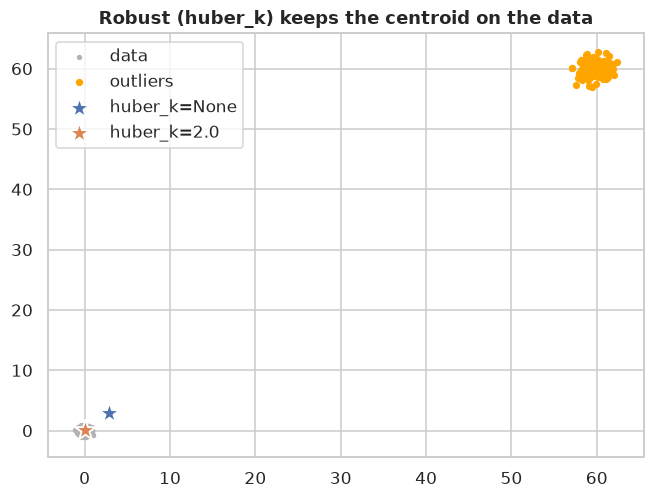

,setting,centroid,"dist from true (0,0)"
0,huber_k=None,"[2.86, 2.86]",4.04
1,huber_k=2.0,"[0.03, 0.03]",0.04


In [5]:
tight = rng.normal([0.0, 0.0], 0.3, (4000, 2))
outliers = rng.normal([60.0, 60.0], 1.0, (200, 2))
stream = np.vstack([tight, outliers])  # outliers arrive last

centers = {}
for name, hk in [("huber_k=None", None), ("huber_k=2.0", 2.0)]:
    est = Betula(n_clusters=1, feature="diagonal", method="kmeans", threshold=1e9, seed=1, huber_k=hk).fit(stream)
    centers[name] = est.cluster_centers_[0]
robust_tbl = pd.DataFrame(
    {"setting": list(centers), "centroid": [np.round(c, 2).tolist() for c in centers.values()],
     "dist from true (0,0)": [round(float(np.linalg.norm(c)), 2) for c in centers.values()]}
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(*tight.T, s=6, color="0.7", label="data")
ax.scatter(*outliers.T, s=14, color="orange", label="outliers")
for name, c in centers.items():
    ax.scatter(*c, s=200, marker="*", edgecolor="white", linewidth=1.2, label=name, zorder=5)
ax.legend()
ax.set_title("Robust (huber_k) keeps the centroid on the data")
plt.show()
robust_tbl

## Memory budgets — size the tree to a target, not by hand

Set `memory_budget_mb` and the estimator derives `max_leaves` for you (from the budget, dimension
and feature model); `effective_max_leaves_` reports what it picked.

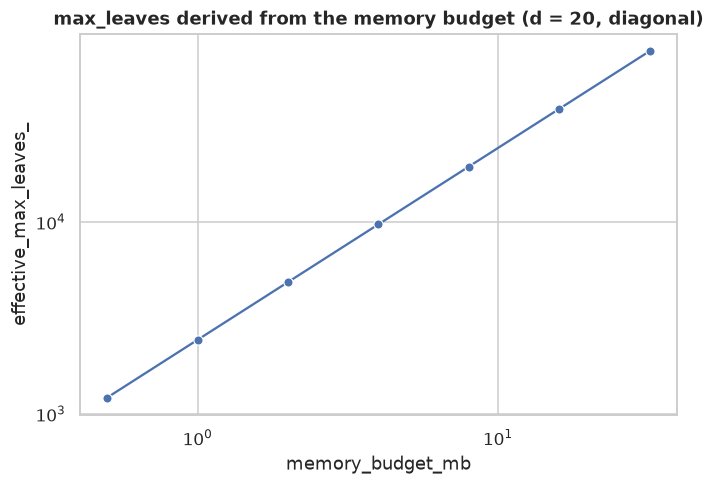

,memory_budget_mb,effective_max_leaves_
0,0.5,1213
1,1.0,2427
2,2.0,4854
3,4.0,9709
4,8.0,19418
5,16.0,38836
6,32.0,77672


In [6]:
Xb, _ = make_blobs(n_samples=40_000, n_features=20, centers=8, random_state=0)
Xb = Xb.astype(np.float64)
budgets = [0.5, 1, 2, 4, 8, 16, 32]
leaves = []
for mb in budgets:
    e = Betula(n_clusters=8, feature="diagonal", method="kmeans", threshold=0.5, memory_budget_mb=mb, seed=1).fit(Xb)
    leaves.append(e.effective_max_leaves_)
budget_tbl = pd.DataFrame({"memory_budget_mb": budgets, "effective_max_leaves_": leaves})

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.lineplot(data=budget_tbl, x="memory_budget_mb", y="effective_max_leaves_", marker="o", ax=ax)
ax.set(xscale="log", yscale="log", title="max_leaves derived from the memory budget (d = 20, diagonal)")
plt.show()
budget_tbl